<a href="https://colab.research.google.com/github/jmurciaCONTRACTUAL/contractual/blob/main/DatosContractuales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   BS ITEM                 30 non-null     int64 
 1   GRUPO OFISI             30 non-null     object
 2   AGRUPACION              30 non-null     int64 
 3   SOLICITUD GESDOC CF     30 non-null     object
 4   ESTADO DE SOLICITUD CF  30 non-null     object
 5   GESTOR SOLICITUD CF     30 non-null     object
 6   RESPUESTA GESDOC CF     30 non-null     object
 7   GESTOR RESPUESTA CF     30 non-null     object
dtypes: int64(2), object(6)
memory usage: 2.0+ KB
            BS ITEM  AGRUPACION
BS ITEM     1.00000     0.08012
AGRUPACION  0.08012     1.00000
Correlación de columnas numéricas:
            BS ITEM  AGRUPACION
BS ITEM     1.00000     0.08012
AGRU

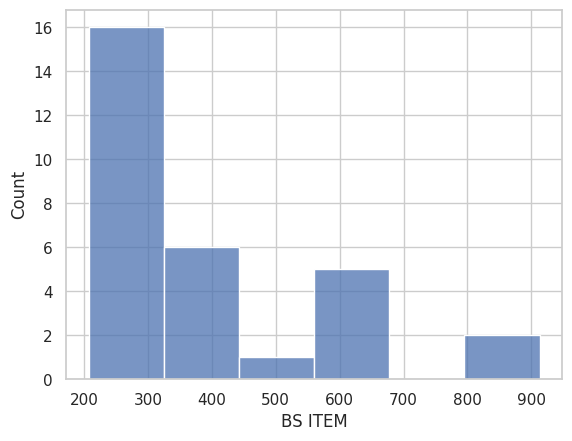

In [4]:
import numpy as np
import pandas as pd
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64
import sqlite3
import pandas as pd
import os
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

os.listdir('/content/drive/MyDrive') #validar lo que se subio en myDrive, un listado de todas las carpetas
#!ls "/content/drive/MyDrive/folders/Precontractual2026.xls"#validar lo que se subio en myDrive, un listado de todas las carpetas

archivo = "/content/drive/MyDrive/OFISI/2026_Gestion_OFISI/Contratacion_2026/ModeloSemantico_SeguimientoContratacion/Precontractual2026.xlsx"

df = pd.read_excel(archivo)
df.head()

df.info()
df.describe()
df.isnull().sum()
df = df.dropna()

#####CORRELACIONES DE DATOS######


#df.corr()  # Se comenta la línea problemática

# Para calcular la correlación, necesitas seleccionar solo las columnas numéricas.
# Puedes hacer esto de varias maneras:

# Opción 1: Seleccionar explícitamente las columnas numéricas
numeric_df = df[['BS ITEM', 'AGRUPACION']]
print(numeric_df.corr())

# Opción 2: Seleccionar automáticamente todas las columnas numéricas
numeric_df = df.select_dtypes(include=np.number)
print('Correlación de columnas numéricas:')
print(numeric_df.corr())

sns.histplot(df["BS ITEM"])
plt.show()

!pip install pandas gspread oauth2client

sns.set(style="whitegrid")


Una vez autenticado, para interactuar con BigQuery, puedes usar la biblioteca `pandas-gbq`. Necesitarás proporcionar el `project_id` de tu proyecto de Google Cloud. Reemplaza `"your-gcp-project-id"` con el ID de tu proyecto.

**CREAR ANALISIS DE DATOS**

---



Primeras filas del dataset:
   BS ITEM GRUPO OFISI  AGRUPACION SOLICITUD GESDOC CF ESTADO DE SOLICITUD CF  \
0      803       GUASE           0           No aplica              No aplica   
1      207       GRATI           9       2025IE0019617             CF emitido   
2      344       GRATI          10       2025IE0084599             CF emitido   
3      339       GUASE          11       2025IE0103393             CF emitido   
4      352       GUASE          12       2025IE0000839             CF emitido   

            GESTOR SOLICITUD CF RESPUESTA GESDOC CF   GESTOR RESPUESTA CF  
0                     No aplica           No aplica             No aplica  
1        Edwin Mauricio Romero        2025IE0025812  Ana Cristina Díaz M.  
2        Edwin Guerrero Perdomo       2025IE0127772  Ana Cristina Díaz M.  
3  Brigith Alejandra Giraldo G.       2025IE0115163  Ana Cristina Díaz M.  
4     Giovany Baquero Castañeda       2025IE0000839  Ana Cristina Díaz M.  

Promedios:
BS ITEM       366

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


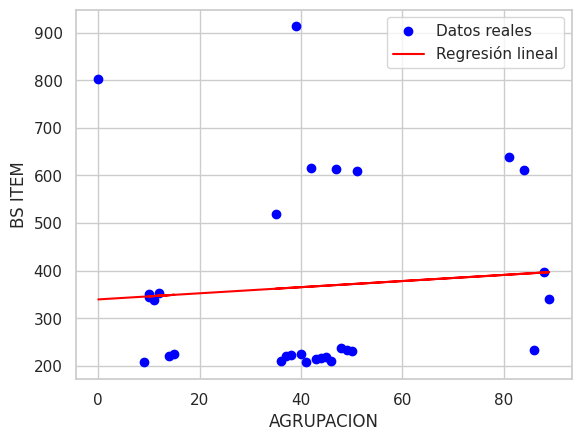

In [5]:
from sklearn.linear_model import LinearRegression

print("Primeras filas del dataset:")
print(df.head())

df = df.dropna()

## Promedio de cada columna numérica
print("\nPromedios:")
print(df.mean(numeric_only=True))

# Correlación entre variables
correlation = df.corr(numeric_only=True)
print("\nMatriz de correlación:")
print(correlation)

modelo = LinearRegression()
X = numeric_df[['AGRUPACION']] # Independent variable(s)
y = numeric_df['BS ITEM']      # Dependent variable
modelo.fit(X, y) #ejecución de la regresión lineal datos actuales

intercepto = modelo.intercept_ # modelar un modelo que despues de la funcion matematica entregue una predicción del comportamiento de los datos
pendiente = modelo.coef_[0]
print("Intercepto:", intercepto)
print("Pendiente:", pendiente)

# Predicción
agrupacion_nueva = np.array([[55]])# entrenamiento de 55 datos o los primeros
prediccion = modelo.predict(agrupacion_nueva)#modelar una predicción de datos
print("Predicción para AGRUPACION = 55:", prediccion[0])

# Graficar
plt.scatter(X, y, color="blue", label="Datos reales")
# To plot the regression line, predict y-values for all X points or a range of X points
plt.plot(X, modelo.predict(X), color="red", label="Regresión lineal")
plt.xlabel("AGRUPACION")
plt.ylabel("BS ITEM")
plt.legend()
plt.show()

**VISUALIZACION DE DATOS**

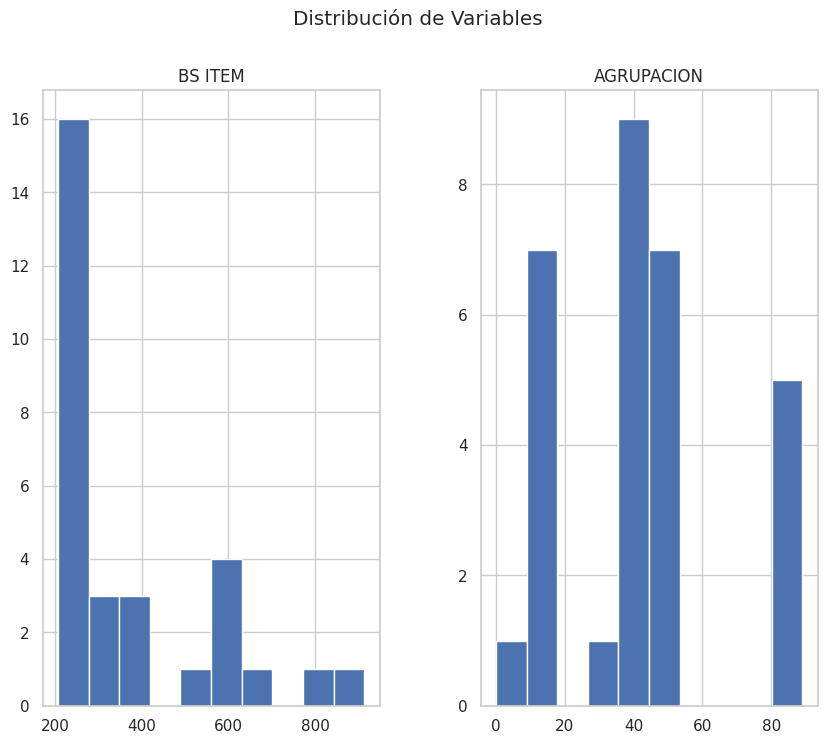

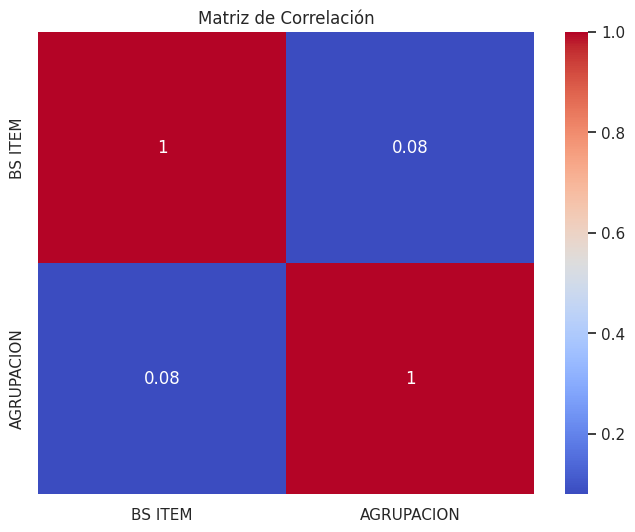


Análisis finalizado. Archivo limpio guardado como 'datos_limpios.csv'


In [6]:
# Histograma de todas las variables numéricas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de Variables")
plt.show()

# Mapa de calor de correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# Gráfico de dispersión (ejemplo entre dos columnas)
# Cambia "columna1" y "columna2"
if "columna1" in df.columns and "columna6" in df.columns:
    sns.scatterplot(data=df, x="columna1", y="columna6")
    plt.title("Relación entre columna1 y columna6")
    plt.show()


# 8. EXPORTAR RESULTADOS
df.to_csv("datos_limpios.csv", index=False)

print("\nAnálisis finalizado. Archivo limpio guardado como 'datos_limpios.csv'")

**EXPORTAR A** **DASHBOARD**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.2 MB/s eta 0:00:00


2026-03-20 13:11:46.273 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 13:11:46.275 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 13:11:46.584 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-20 13:11:46.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 13:11:46.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 13:11:46.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 13:11:46.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

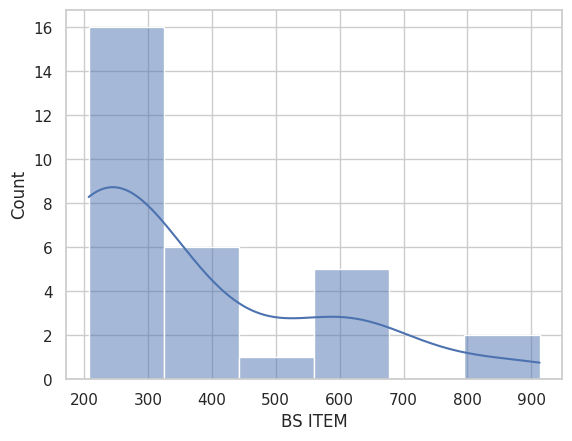

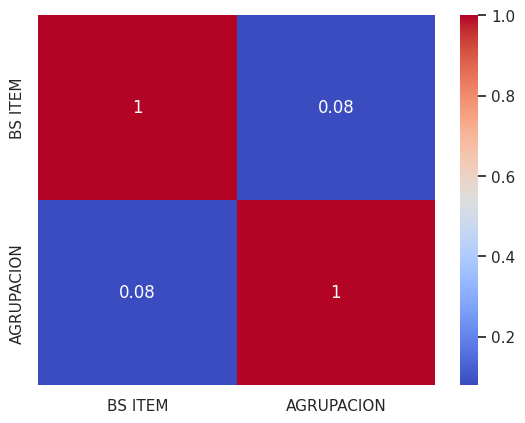

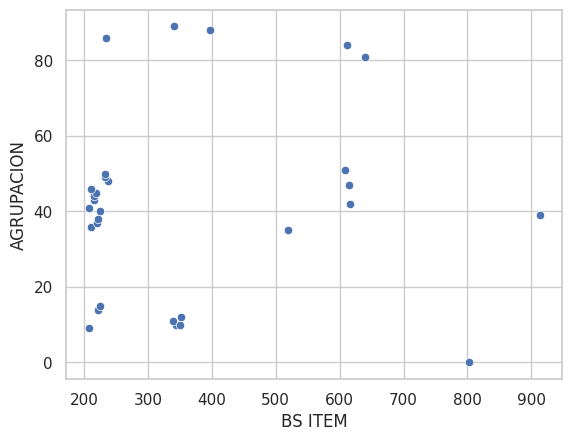

In [10]:
!pip install streamlit pandas matplotlib seaborn

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for numeric type selection

st.set_page_config(layout="wide") # Optional: set page layout for better dashboard appearance

st.title("Dashboard de Análisis de Datos")

# Previous error explanation:
# The 'HTTP Error 401: Unauthorized' occurred because `pd.read_csv` was attempting
# to access a Google Drive sharing link without proper authorization. Google Drive
# sharing links (like '.../edit?usp=drive_link...') are not direct download links
# that pandas can read directly. They typically require browser interaction or
# specific Google Drive API authentication. Additionally, the original URL
# pointed to an Excel file (.xlsx), not a CSV, meaning `pd.read_csv` would have
# been the wrong function even with authorization.

# Fix: Load the 'datos_limpios.csv' file that was created in the previous cell.
# This assumes the intent is to visualize the data that has already been processed.
try:
    df = pd.read_csv("datos_limpios.csv")
    st.success("Datos cargados correctamente desde 'datos_limpios.csv'")
except FileNotFoundError:
    st.error("Error: 'datos_limpios.csv' no encontrado. Por favor, asegúrate de que el archivo fue exportado en las celdas anteriores.")
    st.stop() # Stop the Streamlit app if data cannot be loaded

st.subheader("Vista de Datos")
st.dataframe(df)

st.subheader("Información del dataset")
st.write(df.describe())

# Select numeric columns for plotting
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if numeric_cols:
    columna_hist = st.selectbox("Selecciona una columna para el histograma", numeric_cols)
    if columna_hist:
        st.subheader("Histograma")
        fig, ax = plt.subplots()
        sns.histplot(df[columna_hist], kde=True, ax=ax)
        st.pyplot(fig)

    st.subheader("Correlación")
    # Calculate correlation only for numeric columns
    corr = df[numeric_cols].corr()

    fig2, ax2 = plt.subplots()
    sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax2)
    st.pyplot(fig2)

    # Gráfico de dispersión (ejemplo entre dos columnas numéricas)
    if len(numeric_cols) >= 2:
        st.subheader("Gráfico de Dispersión")
        col1_scatter = st.selectbox("Selecciona la primera columna para el gráfico de dispersión", numeric_cols, index=0)
        # Ensure index for second selectbox is valid
        col2_scatter_index = 1 if len(numeric_cols) > 1 else 0
        col2_scatter = st.selectbox("Selecciona la segunda columna para el gráfico de dispersión", numeric_cols, index=col2_scatter_index)

        if col1_scatter and col2_scatter and col1_scatter != col2_scatter:
            fig_scatter, ax_scatter = plt.subplots()
            sns.scatterplot(data=df, x=col1_scatter, y=col2_scatter, ax=ax_scatter)
            st.pyplot(fig_scatter)
        else:
            st.info("Selecciona dos columnas diferentes para el gráfico de dispersión.")
    else:
        st.warning("Se necesitan al menos dos columnas numéricas para mostrar un gráfico de dispersión.")
else:
    st.warning("No hay columnas numéricas en el dataset para realizar histogramas o correlaciones.")

# Note: The original 'archivo = st.file_uploader(...)' block was commented out
# and is removed for clarity, as 'datos_limpios.csv' is now the primary input.
# If you wish to allow file uploads, that section would need to be re-integrated
# carefully, possibly making 'datos_limpios.csv' a default or initial state.